# Libraries & Setup

In [2]:
import pandas as pd
import numpy as np
import re
import os
import nltk
import matplotlib.pyplot as plt
import seaborn

from pathlib import Path
from nltk.probability import FreqDist
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import ngrams
from nltk import bigrams as make_bigrams
from collections import Counter
from tqdm.auto import tqdm

In [3]:
import ssl

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/juandiegocalixto/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/juandiegocalixto/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/juandiegocalixto/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/juandiegocalixto/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/juandiegocalixto/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/juandiegocalixto/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# Datasets

## Creation

In [4]:
def create_speeches_df(root_dir):
    root_dir = Path(root_dir)
    data = []

    # Iter for the folders inside TXT
    for subfolder in sorted(root_dir.iterdir()):
        if not subfolder.is_dir():
            continue

        # Extract session number and year from the folder name, e.g. "Session 25 - 1970"
        match = re.match(r"Session (\d+) - (\d+)", subfolder.name)
        if not match:
            continue  # skip anything that doesn't match the expected pattern
        session_number, year = int(match.group(1)), int(match.group(2))

        for file in subfolder.iterdir():
            if not file.is_file() or file.name.startswith("."):
                continue

            country_code = file.name.split("_")[0]
            with open(file, encoding="utf-8") as f:
                speech_text = f.read()

            data.append([session_number, year, country_code, speech_text])

    return pd.DataFrame(data, columns=['session_number', 'year', 'country_code', 'speech_text'])

In [5]:
def create_df_from_csv(file_path,sep=','):
    df = pd.read_csv(file_path, sep=sep)
    return df

In [6]:
df_speeches_raw = create_speeches_df('data/TXT')
display(df_speeches_raw.info())
display(df_speeches_raw.sample(10))

<class 'pandas.DataFrame'>
RangeIndex: 11141 entries, 0 to 11140
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   session_number  11141 non-null  int64
 1   year            11141 non-null  int64
 2   country_code    11141 non-null  str  
 3   speech_text     11141 non-null  str  
dtypes: int64(2), str(2)
memory usage: 348.3 KB


None

,session_number,year,country_code,speech_text
3557,39,1984,HND,﻿We are on the eve of a great celebration. In ...
6139,54,1999,MLT,﻿I join other delegations in\ncongratulating y...
2372,30,1975,OMN,﻿\n146.\t It gives me great pleasure to extend...
689,14,1959,LKA,121.\tSir Claude COREA (Ceylon); Apart from th...
3746,40,1985,LBY,"At the outset I wish to express, on behalf of ..."
8793,68,2013,BEL,"It was \nin my country, in Ypres, during the F..."
920,17,1962,CHL,"Mr. President, on behalf of the delegation of ..."
8071,65,2010,CHL,\nI wish to begin by conveying our heartfelt \...
4427,44,1989,EGY,﻿\nIt gives me pleasure at the beginning of my...
6835,58,2003,LBN,﻿This\ngreat number of heads of State and Gove...


## Cleaning and Preproccessing

In [7]:
tqdm.pandas()

In [8]:
# Reset index
df_speeches = df_speeches_raw.set_index(['year','country_code'])

# Lowercase the speec
df_speeches['speech_text'] = df_speeches['speech_text'].str.lower()

# Remove special characters
df_speeches['speech_text'] = (
    df_speeches['speech_text']
    .str.replace(r'[^a-zA-Z\s]', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

In [9]:
# Remove stop words
stop = set(stopwords.words('english'))

def remove_stopwords(text):
    tokens = word_tokenize(text)
    new_text = [t for t in tokens if t not in stop]
    return new_text

# Tokenize
df_speeches['tokens'] = df_speeches['speech_text'].progress_apply(remove_stopwords)

  0%|          | 0/11141 [00:00<?, ?it/s]

In [10]:
# Lemmatize
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    lemmatized = []
    for t in tokens:
        lemmatized.append(lemmatizer.lemmatize(t))
    return lemmatized

df_speeches['lemmatization'] = df_speeches['tokens'].progress_apply(lemmatize_tokens)

  0%|          | 0/11141 [00:00<?, ?it/s]

In [11]:
# Determine the length of the speeches
df_speeches['speech_length'] = (
    df_speeches['speech_text']
    .str.split()
    .str.len()
)
df_speeches['tokens_length'] = df_speeches['tokens'].str.len()

In [12]:
df_speeches.sample(5)

,,session_number,speech_text,tokens,lemmatization,speech_length,tokens_length
year,country_code,,,,,,
2010,MEX,65,let me begin by conveying the warm congratulat...,"[let, begin, conveying, warm, congratulations,...","[let, begin, conveying, warm, congratulation, ...",2502,1356
2011,GNB,66,i would first like to congratulate ambassador ...,"[would, first, like, congratulate, ambassador,...","[would, first, like, congratulate, ambassador,...",1627,862
1977,IDN,32,it gives my delegation great pleasure to salut...,"[gives, delegation, great, pleasure, salute, p...","[give, delegation, great, pleasure, salute, pr...",3925,2093
1973,IRQ,28,i should like at the outset of this statement ...,"[like, outset, statement, join, preceded, cong...","[like, outset, statement, join, preceded, cong...",3035,1565
2017,SLB,72,i would like to add to those of others the con...,"[would, like, add, others, congratulations, de...","[would, like, add, others, congratulation, del...",3136,1693


# Exploratory

## Speeches

### Length

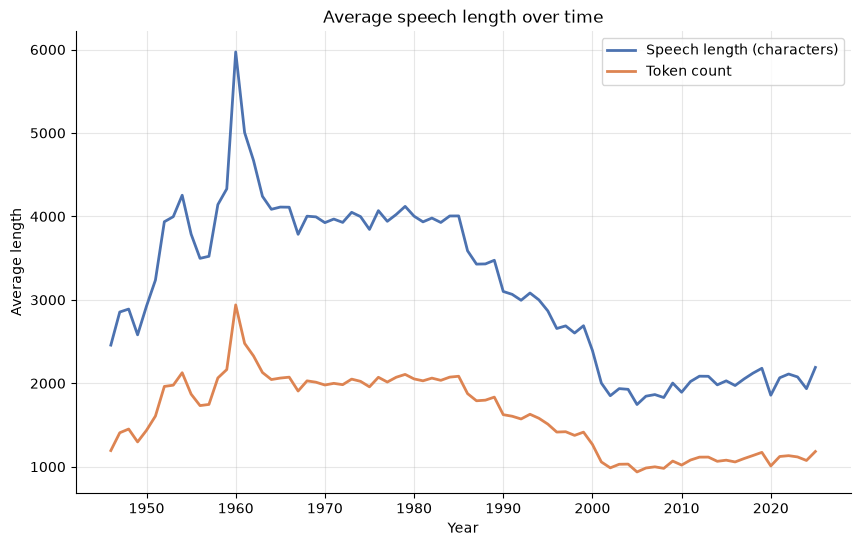

In [13]:
# Lengths of speeches accross time
avg_lengths = df_speeches.groupby(level='year')[['speech_length', 'tokens_length']].mean()

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(avg_lengths.index, avg_lengths['speech_length'],
        color='#4C72B0', linewidth=2, label='Speech length (characters)')
ax.plot(avg_lengths.index, avg_lengths['tokens_length'],
        color='#DD8452', linewidth=2, label='Token count')

ax.set_xlabel('Year')
ax.set_ylabel('Average length')
ax.set_title('Average speech length over time')

ax.legend()
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

### ngrams

In [14]:
df_ngrams = df_speeches.copy()

In [15]:
# Unigrams
unigrams = {
    'warming','carbon','dioxide','emissions','greenhouse','fossil','methane','ozone','atmosphere',
    'drought','wildfires','flooding','deforestation',
    'climate','weather','renewable'
    }

In [16]:
# Corpus pairs
ngrams_2 = Counter(p for toks in df_speeches['lemmatization'] for p in make_bigrams(toks))

In [33]:
ngrams_2.most_common(1000)

[(('united', 'nation'), 153392),
 (('general', 'assembly'), 40975),
 (('international', 'community'), 32681),
 (('security', 'council'), 29182),
 (('human', 'right'), 26551),
 (('secretary', 'general'), 24832),
 (('united', 'state'), 23387),
 (('developing', 'country'), 22784),
 (('peace', 'security'), 20834),
 (('co', 'operation'), 20264),
 (('middle', 'east'), 15548),
 (('member', 'state'), 14229),
 (('south', 'africa'), 14030),
 (('session', 'general'), 13007),
 (('nuclear', 'weapon'), 12338),
 (('economic', 'social'), 11609),
 (('climate', 'change'), 10876),
 (('sustainable', 'development'), 10644),
 (('international', 'peace'), 10599),
 (('per', 'cent'), 10030),
 (('developed', 'country'), 9940),
 (('would', 'like'), 9416),
 (('soviet', 'union'), 8801),
 (('self', 'determination'), 8539),
 (('international', 'law'), 8271),
 (('international', 'economic'), 7070),
 (('viet', 'nam'), 6984),
 (('people', 'republic'), 6940),
 (('international', 'relation'), 6673),
 (('last', 'year'), 6

In [30]:
# Test for different words the most common bigrams
[(p, c) for p, c in ngrams_2.most_common(10000) if "climate" in p][:30]

[(('climate', 'change'), 10876),
 (('convention', 'climate'), 979),
 (('impact', 'climate'), 687),
 (('effect', 'climate'), 658),
 (('agreement', 'climate'), 601),
 (('climate', 'action'), 519),
 (('international', 'climate'), 473),
 (('climate', 'crisis'), 429),
 (('political', 'climate'), 373),
 (('global', 'climate'), 250),
 (('climate', 'peace'), 239),
 (('challenge', 'climate'), 229),
 (('fight', 'climate'), 226),
 (('issue', 'climate'), 210),
 (('address', 'climate'), 197),
 (('create', 'climate'), 185),
 (('climate', 'finance'), 182),
 (('climate', 'fund'), 173),
 (('consequence', 'climate'), 162),
 (('panel', 'climate'), 159),
 (('threat', 'climate'), 156),
 (('new', 'climate'), 155),
 (('green', 'climate'), 155),
 (('climate', 'financing'), 146),
 (('climate', 'confidence'), 145),
 (('climate', 'conducive'), 143),
 (('development', 'climate'), 142),
 (('combat', 'climate'), 140)]

In [18]:
# Bigrams
bigrams = {
    # Energy
    ('renewable', 'energy'),('energy', 'resource'),('energy', 'crisis'),
    ('energy', 'source'),('clean', 'energy'),('sustainable', 'energy'),
    # Climate
    ('climate', 'change'),('climate', 'crisis'),
    # Carbon
    ('carbon','dioxide'),('carbon','emission'),
    # Other
    ('global','warming'),('carbon','dioxide'),('extreme','weather'),
    ('greenhouse','gas'),('greenhouse','gases'),('natural','disasters'),
    ('fossil','fuels'),('gas', 'emission'),
    # Natural
    ('natural', 'resource'),('natural', 'disaster')
   }

In [19]:
# Count appereances in speeches
def count_terms(tokens):
    uni = sum(1 for u in tokens if u in unigrams)
    bi = sum(1 for b in make_bigrams(tokens) if b in bigrams)
    return pd.Series({'unigram_count':uni, 'bigram_count':bi})

df_ngrams[['unigram_count','bigram_count']]= df_ngrams['lemmatization'].progress_apply(count_terms)

  0%|          | 0/11141 [00:00<?, ?it/s]

In [20]:
# See the speech with the higher count
df_ngrams.sort_values('unigram_count',ascending=False)['speech_text'].iloc[0]

'last friday ushered in a new era in our search for an innovative plan of action for people and the planet the significant milestone event was the adoption by the united nations of the new set of sustainable development goals as part of the agenda for sustainable development resolution our sustainable development goals are inspirational and ambitious they are global in nature and universally applicable to every united nations member state developed and developing alike every goal is important and deserves priority attention they are interrelated they carry equal weight and they all matter achieving some goals at the expense of others is not a preferred option all goals must be realized which should be the overriding objective in my firm belief in the importance of the work of our organization i have tried to attend the annual general assembly debates as often as possible since becoming samoa s prime minister i am therefore acutely aware of the diversity and gravity of issues confrontin

In [21]:
# Determine if a speech has or not unigrams or bigrams
df_ngrams['has_unigram'] = df_ngrams['unigram_count'].apply(lambda x: 1 if x > 0 else 0)
df_ngrams['has_bigram'] = df_ngrams['bigram_count'].apply(lambda x: 1 if x > 0 else 0)

In [22]:
# Rate of mentions per speech
df_ngrams['unigram_rate'] = df_ngrams['unigram_count']/df_ngrams['tokens_length']*1000
df_ngrams['bigram_rate'] = df_ngrams['bigram_count']/df_ngrams['tokens_length']*1000

In [23]:
# Agroupation by year

# Option A mean of ratios
yearly_A = df_ngrams.groupby('year')[['unigram_rate','bigram_rate']].mean()

# Option general proportion
yearly_B = df_ngrams.groupby('year')[['unigram_count','bigram_count','tokens_length']].sum()
yearly_B['yearly_unigram_rate'] = yearly_B['unigram_count']/yearly_B['tokens_length']*1000
yearly_B['yearly_bigram_rate'] = yearly_B['bigram_count']/yearly_B['tokens_length']*1000

# Option to count countries that incorporated terms in their speeches
yearly_C = df_ngrams.groupby('year')[['has_unigram','has_bigram']].sum()


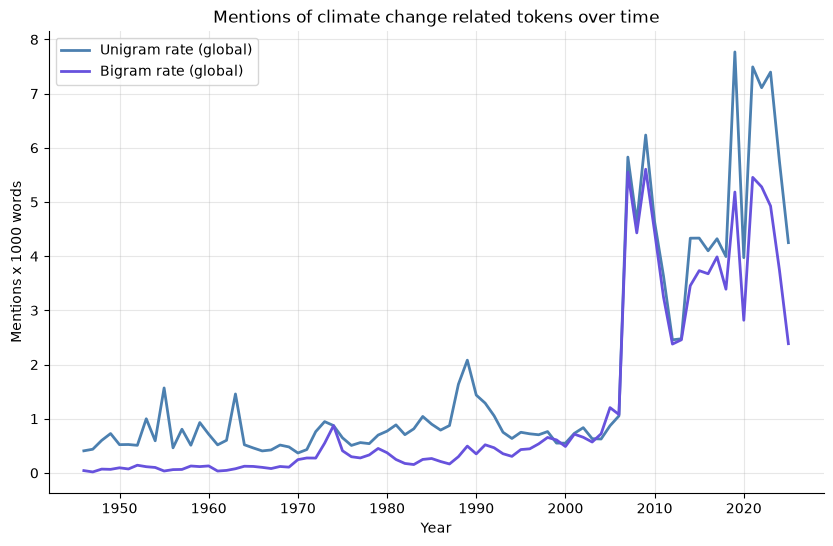

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))

# ax.plot(yearly_A.index, yearly_A['unigram_rate'],
#         color="#B08F4C", linewidth=2, label='Unigram rate (mean of means)')
# ax.plot(yearly_A.index, yearly_A['bigram_rate'],
#         color="#DD9152", linewidth=2, label='Bigram rate (mean of means)')

ax.plot(yearly_B.index, yearly_B['yearly_unigram_rate'],
        color="#4C80B0", linewidth=2, label='Unigram rate (global)')
ax.plot(yearly_B.index, yearly_B['yearly_bigram_rate'],
        color="#6752DD", linewidth=2, label='Bigram rate (global)')

ax.set_xlabel('Year')
ax.set_ylabel('Mentions x 1000 words')
ax.set_title('Mentions of climate change related tokens over time')

ax.legend()
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

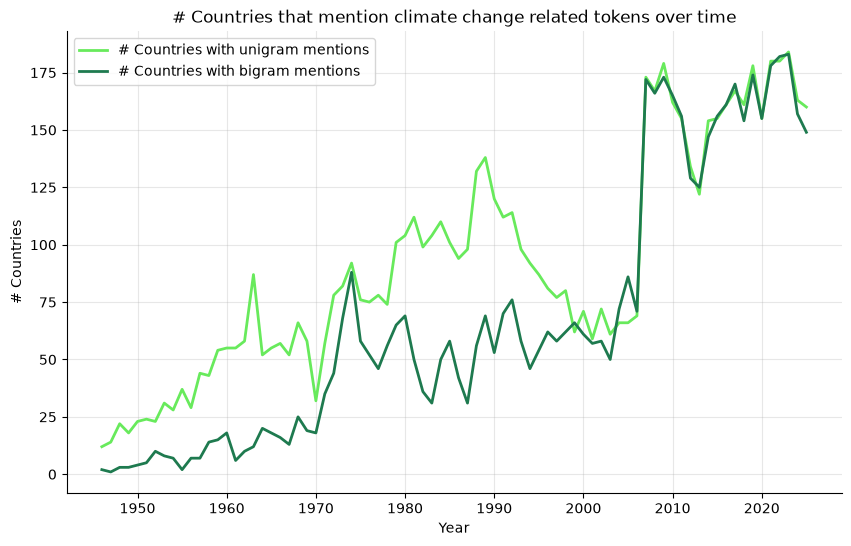

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(yearly_C.index, yearly_C['has_unigram'],
        color="#68EA5C", linewidth=2, label='# Countries with unigram mentions')
ax.plot(yearly_C.index, yearly_C['has_bigram'],
        color="#1E7A4F", linewidth=2, label='# Countries with bigram mentions')

ax.set_xlabel('Year')
ax.set_ylabel('# Countries')
ax.set_title('# Countries that mention climate change related tokens over time')

ax.legend()
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

### Climate change vs energy frequency

In [26]:
df_cc_vs_re = df_speeches.copy()

In [27]:
# Bigrams

# Energy
re_bigrams = {
    # Energy
    ('renewable', 'energy'),('energy', 'resource'),('energy', 'crisis'),
    ('energy', 'source'),('clean', 'energy'),('sustainable', 'energy')
   }

# Climate change
cc_bigrams = {
    # Climate
        ('climate', 'change'),('climate', 'crisis'),
        # Carbon
        ('carbon','dioxide'),('carbon','emission'),
        # Other
        ('global','warming'),('carbon','dioxide'),('extreme','weather'),
        ('greenhouse','gas'),('greenhouse','gases'),('natural','disasters'),
        ('fossil','fuels'),('gas', 'emission'),
        # Natural
        ('natural', 'resource'),('natural', 'disaster')
    }

In [28]:
# Count appereances in speeches
def count_vs_terms(tokens):
    energy = sum(1 for u in tokens if u in re_bigrams)
    climate = sum(1 for b in make_bigrams(tokens) if b in cc_bigrams)
    return pd.Series({'renewable_energy_count':energy, 'climate_change_count':climate})

df_cc_vs_re[['unigram_count','bigram_count']]= df_cc_vs_re['lemmatization'].progress_apply(count_vs_terms)

  0%|          | 0/11141 [00:00<?, ?it/s]

In [32]:
df_ngrams.sample(5)

,,session_number,speech_text,tokens,lemmatization,speech_length,tokens_length,unigram_count,bigram_count,has_unigram,has_bigram,unigram_rate,bigram_rate
year,country_code,,,,,,,,,,,,
1950,FRA,5,at the conclusion of this general discussion i...,"[conclusion, general, discussion, much, eloque...","[conclusion, general, discussion, much, eloque...",2579,1242,1,0,1,0,0.805153,0.000000
2000,HND,55,it is an honour for me to address the general ...,"[honour, address, general, assembly, complemen...","[honour, address, general, assembly, complemen...",1704,873,4,3,1,1,4.581901,3.436426
2023,GHA,78,ghana presents its compliments to the presiden...,"[ghana, presents, compliments, president, cong...","[ghana, present, compliment, president, congra...",2140,1034,1,1,1,1,0.967118,0.967118
1976,IRN,31,mr president your election to the presidency o...,"[mr, president, election, presidency, general,...","[mr, president, election, presidency, general,...",3078,1604,2,0,1,0,1.246883,0.000000
2003,CPV,58,let me at the very outset offer my warm congra...,"[let, outset, offer, warm, congratulations, mr...","[let, outset, offer, warm, congratulation, mr,...",2091,1136,0,0,0,0,0.000000,0.000000


In [34]:
df_ngrams['bigram_count'].sum()

np.int64(20290)